# 05 - Dataset Splitting for YOLOv8 Retail Theft Detection

**Purpose:** Verify and optionally re-split dataset with stratification

**Objectives:**
- Analyze current train/val/test split ratios
- Verify class distribution preservation across splits
- Check for data leakage
- Optionally create new stratified split (70/20/10)
- Generate split statistics and visualization

---

## 1. Setup and Imports

In [1]:
# Install required packages
!pip install opencv-python pillow numpy pandas scikit-learn tqdm pyyaml matplotlib seaborn --quiet

In [2]:
import os
import sys
import yaml
import json
import shutil
import random
from pathlib import Path
from datetime import datetime
from collections import defaultdict
from typing import Dict, List, Tuple, Set

import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Set random seed for reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("All imports successful!")

All imports successful!


In [3]:
# Configuration
BASE_DIR = Path(r"c:/Users/shaho/OneDrive - Nile University/Desktop/AletrixGrad")

# Check for available datasets
AUGMENTED_DIR = BASE_DIR / "dataset_augmented"
CLEANED_DIR = BASE_DIR / "dataset_cleaned"
ORIGINAL_DIR = BASE_DIR / "cc-tv-footage-annotation-b8-lcysc-b1-2"

# Use augmented if available, then cleaned, then original
if AUGMENTED_DIR.exists() and (AUGMENTED_DIR / "train" / "images").exists():
    SOURCE_DIR = AUGMENTED_DIR
    print(f"Using augmented dataset: {SOURCE_DIR}")
elif CLEANED_DIR.exists() and (CLEANED_DIR / "train" / "images").exists():
    SOURCE_DIR = CLEANED_DIR
    print(f"Using cleaned dataset: {SOURCE_DIR}")
else:
    SOURCE_DIR = ORIGINAL_DIR
    print(f"Using original dataset: {SOURCE_DIR}")

OUTPUT_DIR = BASE_DIR / "outputs"
VIS_DIR = BASE_DIR / "visualizations"
FINAL_DATASET_DIR = BASE_DIR / "dataset_final"

# Create directories
OUTPUT_DIR.mkdir(exist_ok=True)
VIS_DIR.mkdir(exist_ok=True)

# Class definitions
CLASS_NAMES = {
    0: 'Customer-Bagpack',
    1: 'Product',
    2: 'Product-Picked',
    3: 'Shopping-Cart',
    4: 'normal',
    5: 'theft'
}
NUM_CLASSES = 6
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp'}

# Target split ratios
TRAIN_RATIO = 0.70
VAL_RATIO = 0.20
TEST_RATIO = 0.10

print(f"\nTarget Split Ratios: Train={TRAIN_RATIO:.0%}, Val={VAL_RATIO:.0%}, Test={TEST_RATIO:.0%}")

Using augmented dataset: c:\Users\shaho\OneDrive - Nile University\Desktop\AletrixGrad\dataset_augmented

Target Split Ratios: Train=70%, Val=20%, Test=10%


## 2. Analyze Current Split

In [4]:
def analyze_split_distribution(dataset_path: Path) -> Dict:
    """Analyze the current dataset split distribution."""
    
    results = {
        'splits': {},
        'total_images': 0,
        'total_annotations': 0
    }
    
    for split in ['train', 'valid', 'test']:
        split_path = dataset_path / split
        images_path = split_path / "images"
        labels_path = split_path / "labels"
        
        if not images_path.exists():
            continue
        
        split_data = {
            'num_images': 0,
            'num_labels': 0,
            'num_annotations': 0,
            'class_counts': defaultdict(int),
            'images': []
        }
        
        # Count images
        image_files = [f for f in images_path.iterdir() 
                       if f.suffix.lower() in IMAGE_EXTENSIONS]
        split_data['num_images'] = len(image_files)
        split_data['images'] = [f.stem for f in image_files]
        
        # Count labels and annotations
        if labels_path.exists():
            label_files = list(labels_path.glob("*.txt"))
            split_data['num_labels'] = len(label_files)
            
            for label_file in label_files:
                try:
                    with open(label_file, 'r') as f:
                        for line in f:
                            parts = line.strip().split()
                            if len(parts) >= 1:
                                try:
                                    class_id = int(parts[0])
                                    split_data['class_counts'][class_id] += 1
                                    split_data['num_annotations'] += 1
                                except ValueError:
                                    pass
                except Exception as e:
                    print(f"Error reading {label_file}: {e}")
        
        results['splits'][split] = split_data
        results['total_images'] += split_data['num_images']
        results['total_annotations'] += split_data['num_annotations']
    
    return results

In [5]:
# Analyze current distribution
print("Analyzing current split distribution...")
split_analysis = analyze_split_distribution(SOURCE_DIR)

print("\n" + "="*70)
print("CURRENT SPLIT ANALYSIS")
print("="*70)

print(f"\nTotal Images: {split_analysis['total_images']:,}")
print(f"Total Annotations: {split_analysis['total_annotations']:,}")

print("\n" + "-"*70)
print("Split Distribution:")
print("-"*70)

split_ratios = {}
for split_name, split_data in split_analysis['splits'].items():
    ratio = split_data['num_images'] / split_analysis['total_images'] if split_analysis['total_images'] > 0 else 0
    split_ratios[split_name] = ratio
    
    print(f"\n{split_name.upper()}:")
    print(f"  Images:      {split_data['num_images']:,} ({ratio:.1%})")
    print(f"  Labels:      {split_data['num_labels']:,}")
    print(f"  Annotations: {split_data['num_annotations']:,}")

Analyzing current split distribution...

CURRENT SPLIT ANALYSIS

Total Images: 2,803
Total Annotations: 7,335

----------------------------------------------------------------------
Split Distribution:
----------------------------------------------------------------------

TRAIN:
  Images:      2,065 (73.7%)
  Labels:      2,065
  Annotations: 4,726

VALID:
  Images:      482 (17.2%)
  Labels:      482
  Annotations: 1,767

TEST:
  Images:      256 (9.1%)
  Labels:      256
  Annotations: 842


In [6]:
# Class distribution per split
print("\n" + "-"*70)
print("Class Distribution per Split:")
print("-"*70)

# Create DataFrame for comparison
class_per_split = []

for split_name, split_data in split_analysis['splits'].items():
    print(f"\n{split_name.upper()}:")
    split_total = split_data['num_annotations']
    
    for class_id in sorted(split_data['class_counts'].keys()):
        count = split_data['class_counts'][class_id]
        pct = count / split_total * 100 if split_total > 0 else 0
        print(f"  {CLASS_NAMES[class_id]:20s}: {count:5,} ({pct:5.1f}%)")
        
        class_per_split.append({
            'split': split_name,
            'class_id': class_id,
            'class_name': CLASS_NAMES[class_id],
            'count': count,
            'percentage': pct
        })

class_split_df = pd.DataFrame(class_per_split)


----------------------------------------------------------------------
Class Distribution per Split:
----------------------------------------------------------------------

TRAIN:
  Customer-Bagpack    :   398 (  8.4%)
  Product             :   515 ( 10.9%)
  Product-Picked      :   504 ( 10.7%)
  Shopping-Cart       :    91 (  1.9%)
  normal              : 2,963 ( 62.7%)
  theft               :   255 (  5.4%)

VALID:
  Customer-Bagpack    :   148 (  8.4%)
  Product             :   199 ( 11.3%)
  Product-Picked      :   192 ( 10.9%)
  Shopping-Cart       :    27 (  1.5%)
  normal              : 1,114 ( 63.0%)
  theft               :    87 (  4.9%)

TEST:
  Customer-Bagpack    :    59 (  7.0%)
  Product             :    79 (  9.4%)
  Product-Picked      :    82 (  9.7%)
  Shopping-Cart       :    19 (  2.3%)
  normal              :   549 ( 65.2%)
  theft               :    54 (  6.4%)


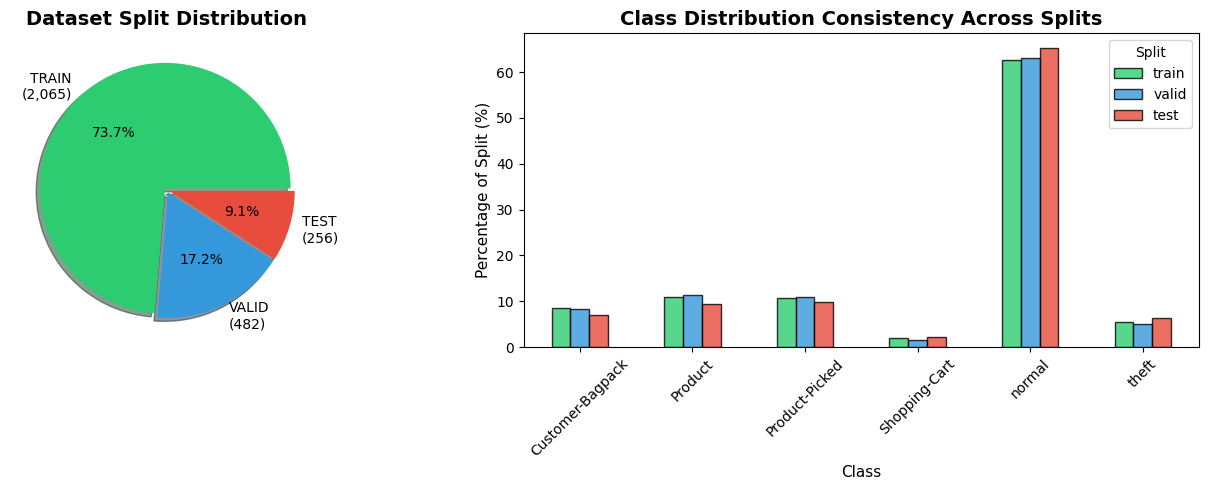

In [7]:
# Visualize split distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Split ratio pie chart
split_names = list(split_analysis['splits'].keys())
split_sizes = [split_analysis['splits'][s]['num_images'] for s in split_names]
colors = {'train': '#2ecc71', 'valid': '#3498db', 'test': '#e74c3c'}
split_colors = [colors.get(s, 'gray') for s in split_names]

wedges, texts, autotexts = axes[0].pie(
    split_sizes, 
    labels=[f"{s.upper()}\n({n:,})" for s, n in zip(split_names, split_sizes)],
    autopct='%1.1f%%', 
    colors=split_colors,
    explode=[0.02] * len(split_names),
    shadow=True
)
axes[0].set_title('Dataset Split Distribution', fontsize=14, fontweight='bold')

# Class distribution per split grouped bar chart
pivot_df = class_split_df.pivot(index='class_name', columns='split', values='percentage')
pivot_df = pivot_df.reindex(columns=['train', 'valid', 'test'])

pivot_df.plot(kind='bar', ax=axes[1], color=[colors.get(c, 'gray') for c in pivot_df.columns], 
              edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Class', fontsize=11)
axes[1].set_ylabel('Percentage of Split (%)', fontsize=11)
axes[1].set_title('Class Distribution Consistency Across Splits', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Split')

plt.tight_layout()
plt.savefig(VIS_DIR / 'split_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Check for Data Leakage

In [8]:
# Check for potential data leakage (same images in multiple splits)
print("\n" + "="*70)
print("DATA LEAKAGE CHECK")
print("="*70)

# Get image stems from each split
train_images = set(split_analysis['splits'].get('train', {}).get('images', []))
valid_images = set(split_analysis['splits'].get('valid', {}).get('images', []))
test_images = set(split_analysis['splits'].get('test', {}).get('images', []))

# Check for overlaps
train_valid_overlap = train_images & valid_images
train_test_overlap = train_images & test_images
valid_test_overlap = valid_images & test_images

print(f"\nTrain-Validation overlap: {len(train_valid_overlap)} images")
print(f"Train-Test overlap: {len(train_test_overlap)} images")
print(f"Validation-Test overlap: {len(valid_test_overlap)} images")

total_overlap = len(train_valid_overlap) + len(train_test_overlap) + len(valid_test_overlap)

if total_overlap == 0:
    print("\n[PASS] No data leakage detected!")
else:
    print(f"\n[WARNING] Data leakage detected! {total_overlap} overlapping images found.")
    if train_valid_overlap:
        print(f"  Train-Valid overlaps: {list(train_valid_overlap)[:5]}...")
    if train_test_overlap:
        print(f"  Train-Test overlaps: {list(train_test_overlap)[:5]}...")
    if valid_test_overlap:
        print(f"  Valid-Test overlaps: {list(valid_test_overlap)[:5]}...")


DATA LEAKAGE CHECK

Train-Validation overlap: 0 images
Train-Test overlap: 0 images
Validation-Test overlap: 0 images

[PASS] No data leakage detected!


## 4. Evaluate Split Quality

In [9]:
# Calculate stratification quality metrics
print("\n" + "="*70)
print("SPLIT QUALITY EVALUATION")
print("="*70)

# Compare ratios to target
print("\nSplit Ratio Comparison:")
print("-"*50)
print(f"{'Split':<10} {'Current':<15} {'Target':<15} {'Difference':<15}")
print("-"*50)

target_ratios = {'train': TRAIN_RATIO, 'valid': VAL_RATIO, 'test': TEST_RATIO}
ratio_diffs = {}

for split, target in target_ratios.items():
    current = split_ratios.get(split, 0)
    diff = current - target
    ratio_diffs[split] = diff
    print(f"{split:<10} {current:>12.1%}    {target:>12.1%}    {diff:>+12.1%}")

# Calculate class distribution consistency (Chi-square like measure)
print("\n" + "-"*70)
print("Class Distribution Consistency:")
print("-"*70)

# Get overall class distribution
total_class_counts = defaultdict(int)
for split_data in split_analysis['splits'].values():
    for class_id, count in split_data['class_counts'].items():
        total_class_counts[class_id] += count

total_annots = sum(total_class_counts.values())
expected_pcts = {cid: count/total_annots*100 for cid, count in total_class_counts.items()}

print(f"\n{'Class':<20} {'Expected %':<12} {'Train %':<12} {'Valid %':<12} {'Test %':<12} {'Max Diff':<12}")
print("-"*80)

max_diffs = []
for class_id in sorted(total_class_counts.keys()):
    expected = expected_pcts[class_id]
    
    split_pcts = []
    for split_name in ['train', 'valid', 'test']:
        if split_name in split_analysis['splits']:
            split_total = split_analysis['splits'][split_name]['num_annotations']
            split_count = split_analysis['splits'][split_name]['class_counts'].get(class_id, 0)
            split_pct = split_count / split_total * 100 if split_total > 0 else 0
            split_pcts.append(split_pct)
        else:
            split_pcts.append(0)
    
    max_diff = max(abs(p - expected) for p in split_pcts)
    max_diffs.append(max_diff)
    
    print(f"{CLASS_NAMES[class_id]:<20} {expected:>10.1f}%  {split_pcts[0]:>10.1f}%  {split_pcts[1]:>10.1f}%  {split_pcts[2]:>10.1f}%  {max_diff:>+10.1f}%")

avg_diff = np.mean(max_diffs)
print(f"\nAverage Max Difference: {avg_diff:.2f}%")

if avg_diff < 2:
    print("[EXCELLENT] Class distributions are well-balanced across splits!")
elif avg_diff < 5:
    print("[GOOD] Class distributions are reasonably balanced.")
else:
    print("[WARNING] Significant class distribution differences across splits.")


SPLIT QUALITY EVALUATION

Split Ratio Comparison:
--------------------------------------------------
Split      Current         Target          Difference     
--------------------------------------------------
train             73.7%           70.0%           +3.7%
valid             17.2%           20.0%           -2.8%
test               9.1%           10.0%           -0.9%

----------------------------------------------------------------------
Class Distribution Consistency:
----------------------------------------------------------------------

Class                Expected %   Train %      Valid %      Test %       Max Diff    
--------------------------------------------------------------------------------
Customer-Bagpack            8.2%         8.4%         8.4%         7.0%        +1.2%
Product                    10.8%        10.9%        11.3%         9.4%        +1.4%
Product-Picked             10.6%        10.7%        10.9%         9.7%        +0.9%
Shopping-Cart         

## 5. Optional: Create New Stratified Split

In [10]:
# Configuration for re-splitting
RESPLIT_DATASET = False  # Set to True to create new stratified split

print("\n" + "="*70)
print("STRATIFIED SPLIT CONFIGURATION")
print("="*70)
print(f"\nRe-split dataset: {RESPLIT_DATASET}")

if not RESPLIT_DATASET:
    print("\nSkipping re-split. Set RESPLIT_DATASET = True to create new stratified split.")
else:
    print(f"\nWill create new split with ratios: Train={TRAIN_RATIO:.0%}, Val={VAL_RATIO:.0%}, Test={TEST_RATIO:.0%}")


STRATIFIED SPLIT CONFIGURATION

Re-split dataset: False

Skipping re-split. Set RESPLIT_DATASET = True to create new stratified split.


In [11]:
def create_stratified_split(source_dir: Path, output_dir: Path,
                            train_ratio: float = 0.7, val_ratio: float = 0.2, test_ratio: float = 0.1,
                            random_state: int = 42) -> Dict:
    """Create stratified train/val/test split based on class presence in images.
    
    Stratification is based on the primary class in each image (most frequent).
    """
    
    # Collect all images from all splits
    all_images = []
    all_labels = []
    image_classes = []  # Primary class for stratification
    
    for split in ['train', 'valid', 'test']:
        images_path = source_dir / split / "images"
        labels_path = source_dir / split / "labels"
        
        if not images_path.exists():
            continue
        
        for img_file in images_path.iterdir():
            if img_file.suffix.lower() not in IMAGE_EXTENSIONS:
                continue
            
            label_file = labels_path / (img_file.stem + '.txt')
            
            # Determine primary class
            primary_class = 4  # default to 'normal'
            class_counts = defaultdict(int)
            
            if label_file.exists():
                try:
                    with open(label_file, 'r') as f:
                        for line in f:
                            parts = line.strip().split()
                            if len(parts) >= 1:
                                try:
                                    class_id = int(parts[0])
                                    class_counts[class_id] += 1
                                except ValueError:
                                    pass
                except:
                    pass
            
            if class_counts:
                # Prioritize minority/critical classes for stratification
                if 5 in class_counts:  # theft
                    primary_class = 5
                elif 3 in class_counts:  # Shopping-Cart
                    primary_class = 3
                elif 0 in class_counts:  # Customer-Bagpack
                    primary_class = 0
                else:
                    primary_class = max(class_counts, key=class_counts.get)
            
            all_images.append(img_file)
            all_labels.append(label_file)
            image_classes.append(primary_class)
    
    print(f"Total images to split: {len(all_images)}")
    
    # Convert to arrays
    images_array = np.array(all_images)
    labels_array = np.array(all_labels)
    classes_array = np.array(image_classes)
    
    # First split: train vs (val+test)
    val_test_ratio = val_ratio + test_ratio
    
    train_imgs, valtest_imgs, train_labels, valtest_labels, train_classes, valtest_classes = train_test_split(
        images_array, labels_array, classes_array,
        test_size=val_test_ratio,
        stratify=classes_array,
        random_state=random_state
    )
    
    # Second split: val vs test
    relative_test_ratio = test_ratio / val_test_ratio
    
    val_imgs, test_imgs, val_labels, test_labels, _, _ = train_test_split(
        valtest_imgs, valtest_labels, valtest_classes,
        test_size=relative_test_ratio,
        stratify=valtest_classes,
        random_state=random_state
    )
    
    # Create output directories
    for split in ['train', 'valid', 'test']:
        (output_dir / split / "images").mkdir(parents=True, exist_ok=True)
        (output_dir / split / "labels").mkdir(parents=True, exist_ok=True)
    
    # Copy files
    splits_data = {
        'train': (train_imgs, train_labels),
        'valid': (val_imgs, val_labels),
        'test': (test_imgs, test_labels)
    }
    
    stats = {}
    
    for split_name, (imgs, labels) in splits_data.items():
        print(f"\nCopying {split_name}: {len(imgs)} images")
        
        for img_path, label_path in tqdm(zip(imgs, labels), total=len(imgs), desc=split_name):
            # Copy image
            dest_img = output_dir / split_name / "images" / img_path.name
            shutil.copy2(img_path, dest_img)
            
            # Copy label if exists
            if label_path.exists():
                dest_label = output_dir / split_name / "labels" / label_path.name
                shutil.copy2(label_path, dest_label)
        
        stats[split_name] = len(imgs)
    
    return stats


if RESPLIT_DATASET:
    print("\nCreating stratified split...")
    
    # Create new split
    split_stats = create_stratified_split(
        SOURCE_DIR, FINAL_DATASET_DIR,
        train_ratio=TRAIN_RATIO, val_ratio=VAL_RATIO, test_ratio=TEST_RATIO,
        random_state=RANDOM_SEED
    )
    
    print("\n" + "-"*70)
    print("New Split Statistics:")
    print("-"*70)
    total = sum(split_stats.values())
    for split, count in split_stats.items():
        print(f"  {split}: {count:,} images ({count/total:.1%})")
    
    # Copy data.yaml
    source_yaml = SOURCE_DIR / "data.yaml"
    if source_yaml.exists():
        with open(source_yaml, 'r') as f:
            data_config = yaml.safe_load(f)
        
        data_config['train'] = 'train/images'
        data_config['val'] = 'valid/images'
        data_config['test'] = 'test/images'
        
        with open(FINAL_DATASET_DIR / 'data.yaml', 'w') as f:
            yaml.dump(data_config, f, default_flow_style=False)
        
        print(f"\ndata.yaml saved to: {FINAL_DATASET_DIR / 'data.yaml'}")
    
    print(f"\nStratified dataset saved to: {FINAL_DATASET_DIR}")

## 6. Final Split Statistics

In [12]:
# Determine which dataset to use for final analysis
if RESPLIT_DATASET and FINAL_DATASET_DIR.exists():
    FINAL_DIR = FINAL_DATASET_DIR
else:
    FINAL_DIR = SOURCE_DIR

print(f"\nFinal dataset location: {FINAL_DIR}")

# Analyze final split
final_analysis = analyze_split_distribution(FINAL_DIR)


Final dataset location: c:\Users\shaho\OneDrive - Nile University\Desktop\AletrixGrad\dataset_augmented


In [13]:
# Save split statistics report
split_report = {
    'timestamp': datetime.now().isoformat(),
    'dataset_path': str(FINAL_DIR),
    'total_images': final_analysis['total_images'],
    'total_annotations': final_analysis['total_annotations'],
    'splits': {},
    'data_leakage_check': {
        'train_valid_overlap': len(train_valid_overlap),
        'train_test_overlap': len(train_test_overlap),
        'valid_test_overlap': len(valid_test_overlap),
        'status': 'PASS' if total_overlap == 0 else 'FAIL'
    }
}

for split_name, split_data in final_analysis['splits'].items():
    ratio = split_data['num_images'] / final_analysis['total_images'] if final_analysis['total_images'] > 0 else 0
    split_report['splits'][split_name] = {
        'num_images': split_data['num_images'],
        'num_labels': split_data['num_labels'],
        'num_annotations': split_data['num_annotations'],
        'ratio': round(ratio, 3),
        'class_distribution': {CLASS_NAMES[k]: v for k, v in split_data['class_counts'].items()}
    }

report_path = OUTPUT_DIR / 'split_statistics_report.json'
with open(report_path, 'w') as f:
    json.dump(split_report, f, indent=2)

print(f"Split statistics saved to: {report_path}")

Split statistics saved to: c:\Users\shaho\OneDrive - Nile University\Desktop\AletrixGrad\outputs\split_statistics_report.json


In [14]:
# Final summary
print("\n" + "="*70)
print("SPLIT ANALYSIS COMPLETE")
print("="*70)

print(f"""
SUMMARY:
--------
Dataset: {FINAL_DIR.name}
Total Images: {final_analysis['total_images']:,}
Total Annotations: {final_analysis['total_annotations']:,}

Split Distribution:
""")

for split_name in ['train', 'valid', 'test']:
    if split_name in final_analysis['splits']:
        data = final_analysis['splits'][split_name]
        ratio = data['num_images'] / final_analysis['total_images'] * 100 if final_analysis['total_images'] > 0 else 0
        print(f"  {split_name.upper()}: {data['num_images']:,} images ({ratio:.1f}%)")

print(f"""
Data Leakage: {'No leakage detected' if total_overlap == 0 else f'{total_overlap} overlapping images found'}

Files saved:
  - Split statistics: {report_path}
  - Visualizations: {VIS_DIR}
""")

print("="*70)


SPLIT ANALYSIS COMPLETE

SUMMARY:
--------
Dataset: dataset_augmented
Total Images: 2,803
Total Annotations: 7,335

Split Distribution:

  TRAIN: 2,065 images (73.7%)
  VALID: 482 images (17.2%)
  TEST: 256 images (9.1%)

Data Leakage: No leakage detected

Files saved:
  - Split statistics: c:\Users\shaho\OneDrive - Nile University\Desktop\AletrixGrad\outputs\split_statistics_report.json
  - Visualizations: c:\Users\shaho\OneDrive - Nile University\Desktop\AletrixGrad\visualizations



---

## Next Steps

After verifying splits, proceed to:
1. **06_preprocessing_pipeline.ipynb** - Image preprocessing for training
2. **07_training_preparation.ipynb** - Configure YOLOv8s training

---